In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()

Saving flood.jpeg to flood.jpeg


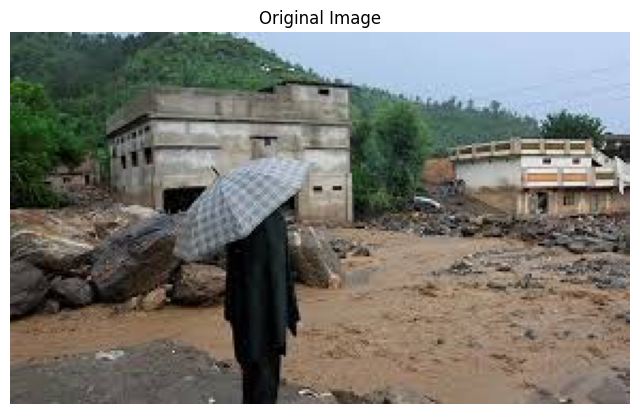

In [4]:
image = cv2.imread("flood.jpeg")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

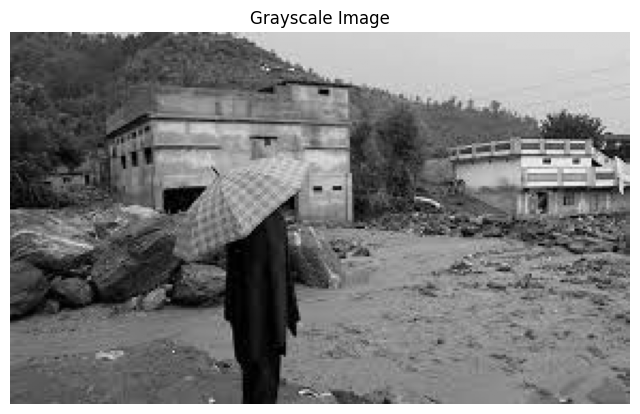

In [5]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

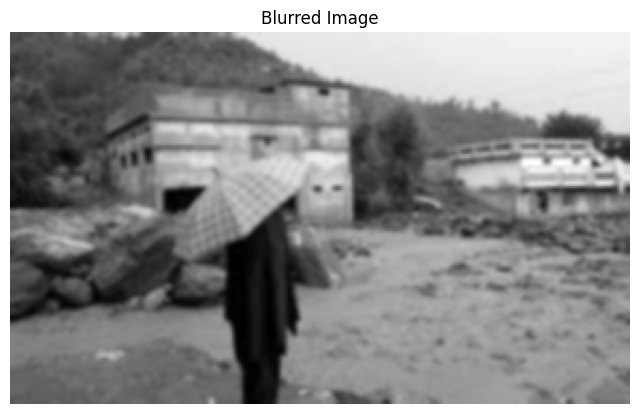

In [6]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(8,6))
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")
plt.show()

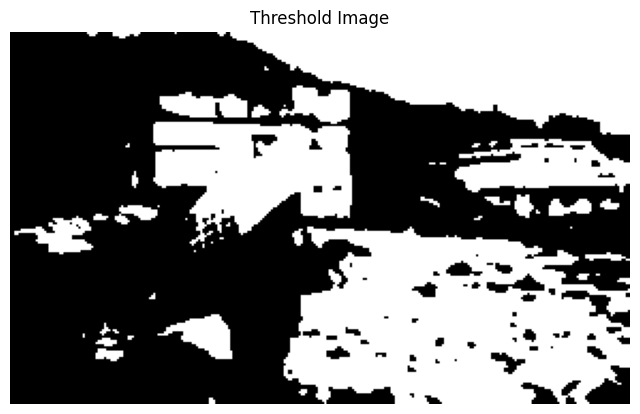

In [7]:
_, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,6))
plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

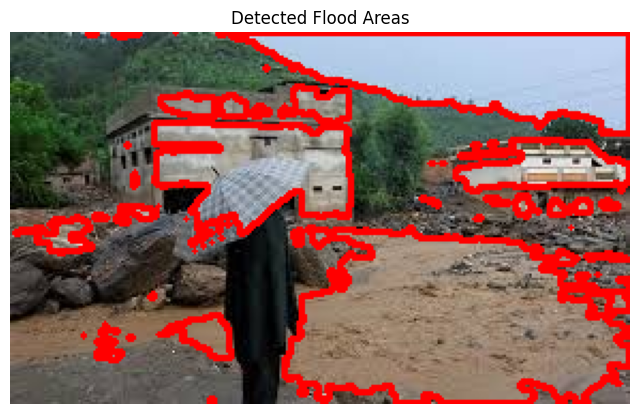

In [8]:
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Copy original image
output = image_rgb.copy()

# Draw contours
cv2.drawContours(output, contours, -1, (255,0,0), 3)

plt.figure(figsize=(8,6))
plt.imshow(output)
plt.title("Detected Flood Areas")
plt.axis("off")
plt.show()

In [9]:
# Total pixels
total_pixels = thresh.size

# White pixels = flooded area
flood_pixels = cv2.countNonZero(thresh)

# Percentage calculation
flood_percentage = (flood_pixels / total_pixels) * 100

print("Flood Affected Area Percentage:")
print(round(flood_percentage, 2), "%")

Flood Affected Area Percentage:
43.69 %


In [10]:
if flood_percentage < 30:
    severity = "LOW FLOOD DAMAGE"
elif flood_percentage < 60:
    severity = "MEDIUM FLOOD DAMAGE"
else:
    severity = "HIGH FLOOD DAMAGE"

print("Severity Level:", severity)

Severity Level: MEDIUM FLOOD DAMAGE


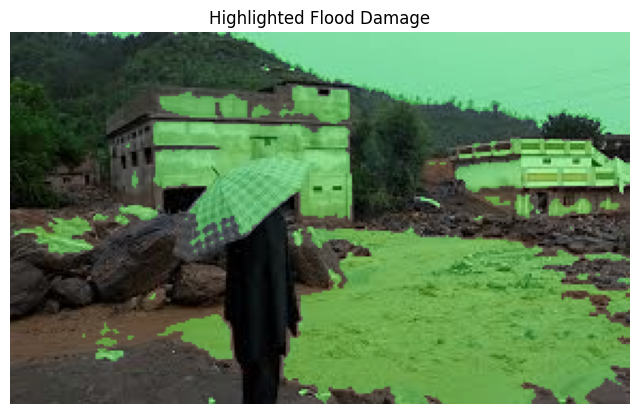

In [11]:
mask = np.zeros_like(image_rgb)

# Fill contours
cv2.drawContours(mask, contours, -1, (0,255,0), thickness=cv2.FILLED)

# Blend original and mask
highlighted = cv2.addWeighted(image_rgb, 0.7, mask, 0.3, 0)

plt.figure(figsize=(8,6))
plt.imshow(highlighted)
plt.title("Highlighted Flood Damage")
plt.axis("off")
plt.show()

Upload a Flood Image


Saving flood.jpeg to flood (1).jpeg


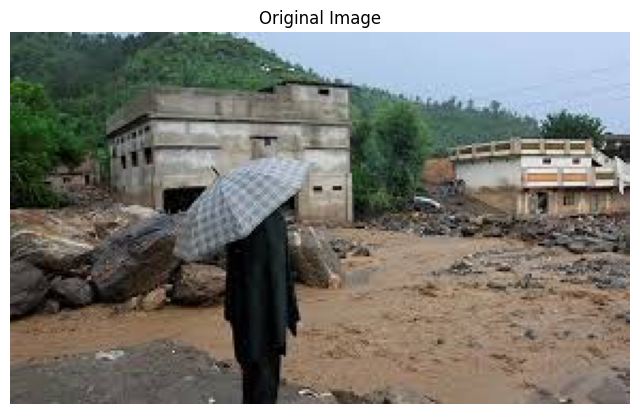

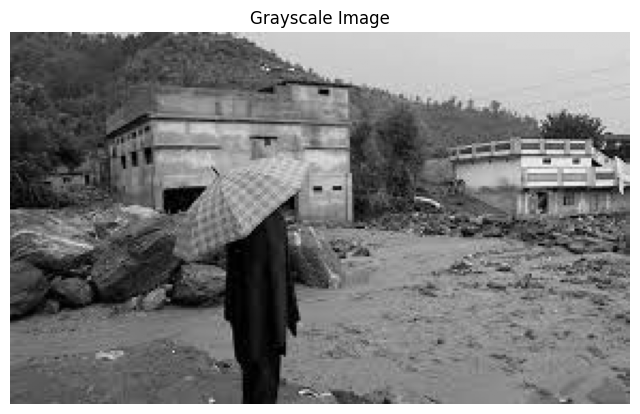

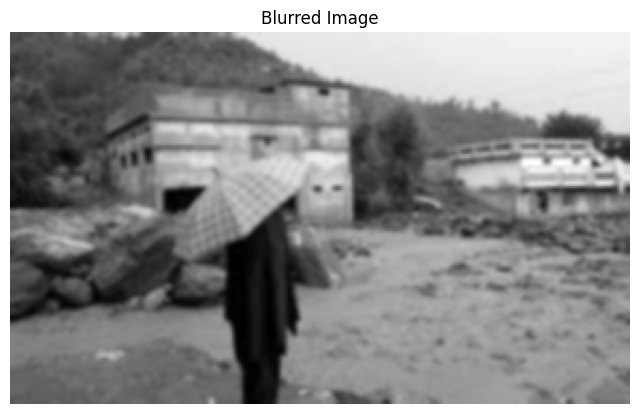

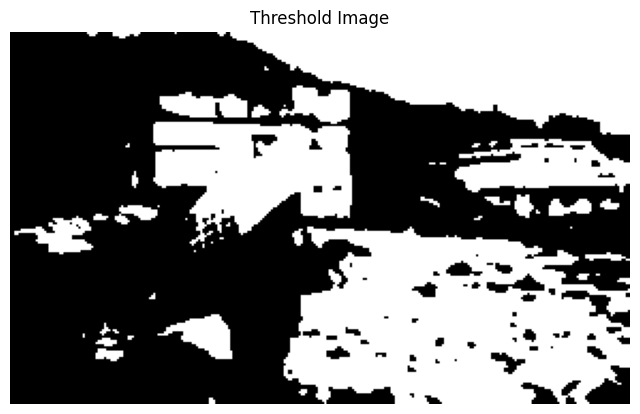

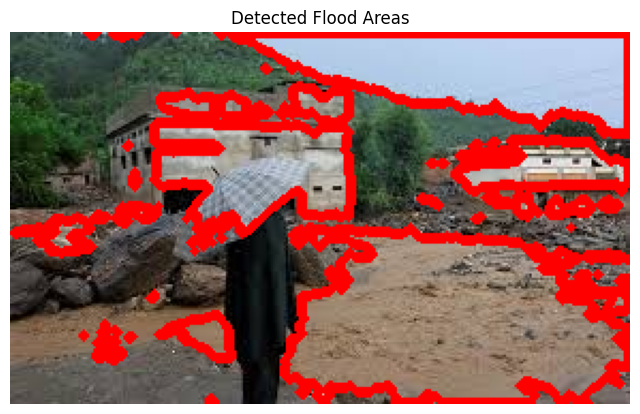

Flood Damage Area Percentage
43.69 %
Severity Level : MEDIUM FLOOD DAMAGE


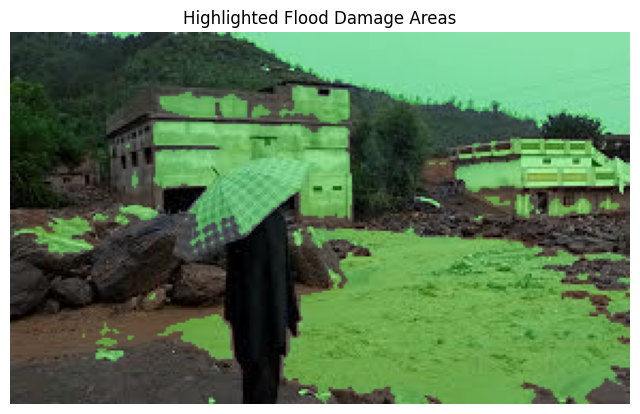

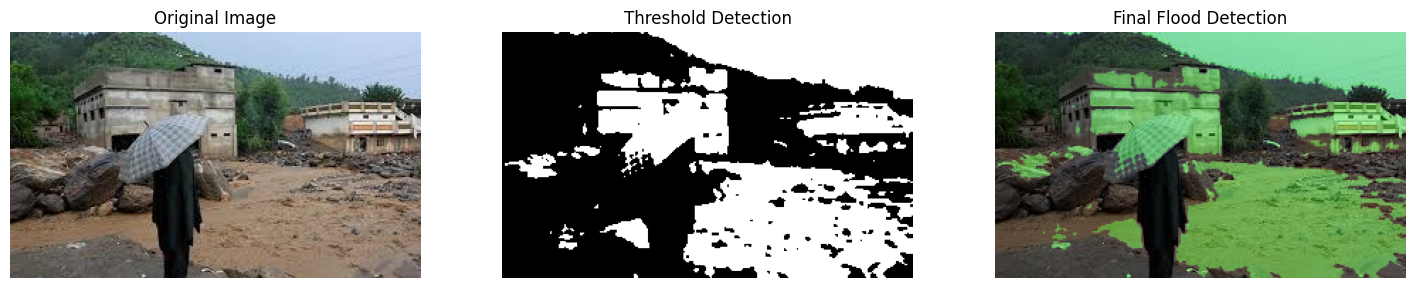


PROJECT OUTPUT
Flood Area Percentage : 43.69 %
Flood Severity Level  : MEDIUM FLOOD DAMAGE
Flood Regions Detected Successfully


In [14]:
# ============================================================
# FLOOD DAMAGE AREA DETECTION USING IMAGE PROCESSING
# ============================================================
# MINI PROJECT USING GOOGLE COLAB + OPENCV
# ============================================================

# Install required libraries
!pip install opencv-python matplotlib

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# STEP 1 : UPLOAD IMAGE
# ============================================================

print("Upload a Flood Image")
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ============================================================
# STEP 2 : DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# ============================================================
# STEP 3 : CONVERT TO GRAYSCALE
# ============================================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# ============================================================
# STEP 4 : APPLY GAUSSIAN BLUR
# ============================================================

blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.figure(figsize=(8,6))
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")
plt.show()

# ============================================================
# STEP 5 : APPLY THRESHOLDING
# ============================================================

# Threshold value can be adjusted
_, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,6))
plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

# ============================================================
# STEP 6 : DETECT FLOOD REGIONS USING CONTOURS
# ============================================================

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Copy original image
output = image_rgb.copy()

# Draw contours around detected flood regions
cv2.drawContours(output, contours, -1, (255,0,0), 3)

plt.figure(figsize=(8,6))
plt.imshow(output)
plt.title("Detected Flood Areas")
plt.axis("off")
plt.show()

# ============================================================
# STEP 7 : CALCULATE FLOOD AREA PERCENTAGE
# ============================================================

# Total number of pixels
total_pixels = thresh.size

# Count white pixels (detected flood area)
flood_pixels = cv2.countNonZero(thresh)

# Calculate percentage
flood_percentage = (flood_pixels / total_pixels) * 100

print("===================================")
print("Flood Damage Area Percentage")
print("===================================")
print(round(flood_percentage, 2), "%")

# ============================================================
# STEP 8 : CLASSIFY FLOOD SEVERITY
# ============================================================

if flood_percentage < 30:
    severity = "LOW FLOOD DAMAGE"
elif flood_percentage < 60:
    severity = "MEDIUM FLOOD DAMAGE"
else:
    severity = "HIGH FLOOD DAMAGE"

print("Severity Level :", severity)

# ============================================================
# STEP 9 : CREATE HIGHLIGHTED FLOOD MASK
# ============================================================

# Create empty mask
mask = np.zeros_like(image_rgb)

# Fill detected regions with green color
cv2.drawContours(mask, contours, -1, (0,255,0), thickness=cv2.FILLED)

# Blend original image with mask
highlighted = cv2.addWeighted(image_rgb, 0.7, mask, 0.3, 0)

plt.figure(figsize=(8,6))
plt.imshow(highlighted)
plt.title("Highlighted Flood Damage Areas")
plt.axis("off")
plt.show()

# ============================================================
# STEP 10 : DISPLAY FINAL RESULTS TOGETHER
# ============================================================

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(thresh, cmap='gray')
ax[1].set_title("Threshold Detection")
ax[1].axis("off")

ax[2].imshow(highlighted)
ax[2].set_title("Final Flood Detection")
ax[2].axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n===================================")
print("PROJECT OUTPUT")
print("===================================")
print("Flood Area Percentage :", round(flood_percentage,2), "%")
print("Flood Severity Level  :", severity)
print("Flood Regions Detected Successfully")
print("===================================")